<a href="https://colab.research.google.com/github/Vbenitez1/Trabajos/blob/main/anime_nlp_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎌 Análisis de Anime con Embeddings, Vectorización y Transformers

**Dataset:** Anime.csv — 18.495 animes con nombre, tags, descripción, rating, estudio, etc.

**Objetivo del proyecto:** Aprender y aplicar los 3 pilares del NLP moderno:
1. **Vectorización** — convertir texto a números (TF-IDF, BoW)
2. **Embeddings** — representaciones densas y semánticas de palabras
3. **Transformers** — modelo BERT para clasificación de sentimiento/rating

**Tarea final:** Clasificar animes como *bien valorados* (rating ≥ 4.0) o *mal valorados* (rating < 4.0)

---
> 📌 **Cómo leer este notebook:**
> - Cada celda tiene comentarios `//` explicando qué hace cada bloque
> - Cada línea de código tiene su comentario `#` explicando qué hace y con qué se conecta
> - El flujo es progresivo: primero lo simple, luego lo sofisticado

---
## 📦 CELDA 1 — Instalación de dependencias
Instalamos las librerías que no vienen por defecto en Colab.
Solo se necesita correr esta celda una vez al inicio de la sesión.

In [35]:
## Instalamos transformers (HuggingFace) y sentencepiece (tokenizador BERT)
## Sin esto no podemos cargar modelos preentrenados como DistilBERT
!pip install transformers sentencepiece --quiet

## Verificamos que PyTorch (el motor de deep learning) esté disponible
## Colab lo incluye por defecto, pero lo confirmamos
!python -c "import torch; print('PyTorch versión:', torch.__version__)"

## Verificamos que Transformers se instaló correctamente
!python -c "import transformers; print('Transformers versión:', transformers.__version__)"

PyTorch versión: 2.11.0+cu128
Transformers versión: 5.0.0


---
## 📥 CELDA 2 — Importaciones globales
Cargamos todas las librerías que usaremos a lo largo del notebook.
Se agrupan por función para que sea fácil identificar de dónde viene cada herramienta.

In [36]:
## ── Manipulación de datos ──────────────────────────────────────────────────
import pandas as pd                    # lee y manipula el CSV como tabla (DataFrame)
import numpy as np                     # operaciones numéricas y vectoriales
import re                              # expresiones regulares para limpiar texto
import warnings                        # permite silenciar advertencias no críticas
warnings.filterwarnings('ignore')      # suprimimos warnings para mantener la salida limpia

## ── Visualización ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt        # gráficas 2D (histogramas, barras, curvas)
import seaborn as sns                  # gráficas estadísticas más bonitas sobre matplotlib
from wordcloud import WordCloud        # nube de palabras para explorar el vocabulario

## ── Vectorización clásica (NLP tradicional) ───────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer   # convierte texto a vectores TF-IDF
from sklearn.feature_extraction.text import CountVectorizer   # convierte texto a vectores BoW (Bag of Words)

## ── División del dataset ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split           # separa datos en train / test

## ── Modelos clásicos de ML (para comparar con Transformers) ──────────────
from sklearn.linear_model import LogisticRegression            # clasificador lineal sobre vectores TF-IDF
from sklearn.svm import LinearSVC                              # Support Vector Machine lineal
from sklearn.metrics import (                                  # métricas de evaluación
    accuracy_score,                                            # proporción de predicciones correctas
    classification_report,                                     # precision, recall, F1 por clase
    confusion_matrix,                                          # matriz de confusión VP/FP/FN/VN
    ConfusionMatrixDisplay                                     # visualización de la matriz
)

## ── Embeddings con Keras (capa entrenable) ────────────────────────────────
import tensorflow as tf                                        # framework de deep learning de Google
from tensorflow.keras.models import Sequential                 # modelo capas apiladas en secuencia
from tensorflow.keras.layers import (                          # capas individuales del modelo
    Embedding,                                                 # tabla de embeddings (índice → vector)
    GlobalAveragePooling1D,                                    # promedia todos los embeddings de la secuencia
    Dense,                                                     # capa densa totalmente conectada
    Dropout                                                    # apaga neuronas aleatoriamente (regularización)
)
from tensorflow.keras.preprocessing.text import Tokenizer     # tokeniza texto y construye vocabulario
from tensorflow.keras.preprocessing.sequence import pad_sequences  # iguala longitudes con padding

## ── Transformers (HuggingFace) ────────────────────────────────────────────
from transformers import (                                     # librería de modelos preentrenados
    AutoTokenizer,                                             # tokenizador automático según el modelo
    AutoModelForSequenceClassification,                        # modelo preentrenado para clasificación
    TrainingArguments,                                         # configuración del entrenamiento
    Trainer                                                    # clase que maneja todo el ciclo de entrenamiento
)
import torch                                                   # motor de tensores y cómputo de gradientes
from torch.utils.data import Dataset                           # clase base para datasets en PyTorch

print('✅ Todas las librerías importadas correctamente')

✅ Todas las librerías importadas correctamente


---
## 📂 CELDA 3 — Carga del dataset
Subimos el archivo CSV desde tu computadora a Colab y lo cargamos en un DataFrame.

In [37]:
## Subimos el archivo Anime.csv desde tu computadora al entorno de Colab
## Esto abre un selector de archivos en tu navegador
from google.colab import files
uploaded = files.upload()              # guarda el archivo en el sistema de archivos temporal de Colab

## Leemos el CSV con pandas
## pd.read_csv convierte el archivo de texto en una tabla (DataFrame)
## encoding='utf-8' maneja caracteres especiales como acentos y kanji
df = pd.read_csv('Anime.csv', encoding='utf-8')   # conecta con el archivo subido arriba

## Mostramos las primeras 3 filas para confirmar que la carga fue exitosa
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')  # shape[0]=filas, shape[1]=columnas
df.head(3)   # muestra las primeras 3 filas del DataFrame

Saving Anime.csv to Anime (1).csv
Dataset cargado: 18,495 filas × 17 columnas


,Rank,Name,Japanese_name,Type,Episodes,Studio,Release_season,Tags,Rating,Release_year,End_year,Description,Content_Warning,Related_Mange,Related_anime,Voice_actors,staff
0,1,Demon Slayer: Kimetsu no Yaiba - Entertainment...,Kimetsu no Yaiba: Yuukaku-hen,TV,NaN,ufotable,Fall,"Action, Adventure, Fantasy, Shounen, Demons, H...",4.60,2021.0,NaN,'Tanjiro and his friends accompany the Hashira...,Explicit Violence,Demon Slayer: Kimetsu no Yaiba,"Demon Slayer: Kimetsu no Yaiba, Demon Slayer: ...","Inosuke Hashibira : Yoshitsugu Matsuoka, Nezuk...","Koyoharu Gotouge : Original Creator, Haruo Sot..."
1,2,Fruits Basket the Final Season,Fruits Basket the Final,TV,13.0,TMS Entertainment,Spring,"Drama, Fantasy, Romance, Shoujo, Animal Transf...",4.60,2021.0,NaN,'The final arc of Fruits Basket.',"Emotional Abuse,, Mature Themes,, Physical Abu...","Fruits Basket, Fruits Basket Another","Fruits Basket 1st Season, Fruits Basket 2nd Se...","Akito Sohma : Maaya Sakamoto, Kyo Sohma : Yuum...","Natsuki Takaya : Original Creator, Yoshihide I..."
2,3,Mo Dao Zu Shi 3,The Founder of Diabolism 3,Web,12.0,B.C MAY PICTURES,NaN,"Fantasy, Ancient China, Chinese Animation, Cul...",4.58,2021.0,NaN,'The third season of Mo Dao Zu Shi.',NaN,Grandmaster of Demonic Cultivation: Mo Dao Zu ...,"Mo Dao Zu Shi 2, Mo Dao Zu Shi Q","Lan Wangji, Wei Wuxian, Jiang Cheng, Jin Guang...","Mo Xiang Tong Xiu : Original Creator, Xiong Ke..."


---
## 🔍 CELDA 4 — Exploración inicial (EDA)
Antes de cualquier modelo, entendemos qué hay en el dataset:
qué columnas existen, cuántos valores nulos hay, qué distribuciones tienen los datos.

In [38]:
## ── Información general del dataset ──────────────────────────────────────
## df.info() imprime: columnas, tipos de dato, cuántos valores no-nulos hay
## Conecta con el paso de limpieza: sabremos qué columnas tienen nulos
print('=== INFORMACIÓN GENERAL ===')
df.info()

print('\n=== VALORES NULOS POR COLUMNA ===')
nulos = df.isnull().sum()              # cuenta cuántos NaN hay en cada columna
print(nulos[nulos > 0])                # mostramos solo las columnas que tienen al menos 1 nulo

print('\n=== ESTADÍSTICAS DE RATING ===')
# describe() calcula media, std, min, max, percentiles de columnas numéricas
# Rating es la variable objetivo: la que intentaremos predecir
print(df['Rating'].describe())

print('\n=== DISTRIBUCIÓN DE TIPOS ===')
# value_counts() cuenta cuántos animes hay de cada tipo (TV, Movie, OVA...)
print(df['Type'].value_counts())

=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18495 entries, 0 to 18494
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             18495 non-null  int64  
 1   Name             18495 non-null  object 
 2   Japanese_name    7938 non-null   object 
 3   Type             18495 non-null  object 
 4   Episodes         9501 non-null   float64
 5   Studio           12018 non-null  object 
 6   Release_season   4116 non-null   object 
 7   Tags             18095 non-null  object 
 8   Rating           15364 non-null  float64
 9   Release_year     18112 non-null  float64
 10  End_year         2854 non-null   float64
 11  Description      18491 non-null  object 
 12  Content_Warning  1840 non-null   object 
 13  Related_Mange    7627 non-null   object 
 14  Related_anime    10063 non-null  object 
 15  Voice_actors     15309 non-null  object 
 16  staff            13005 non-nul

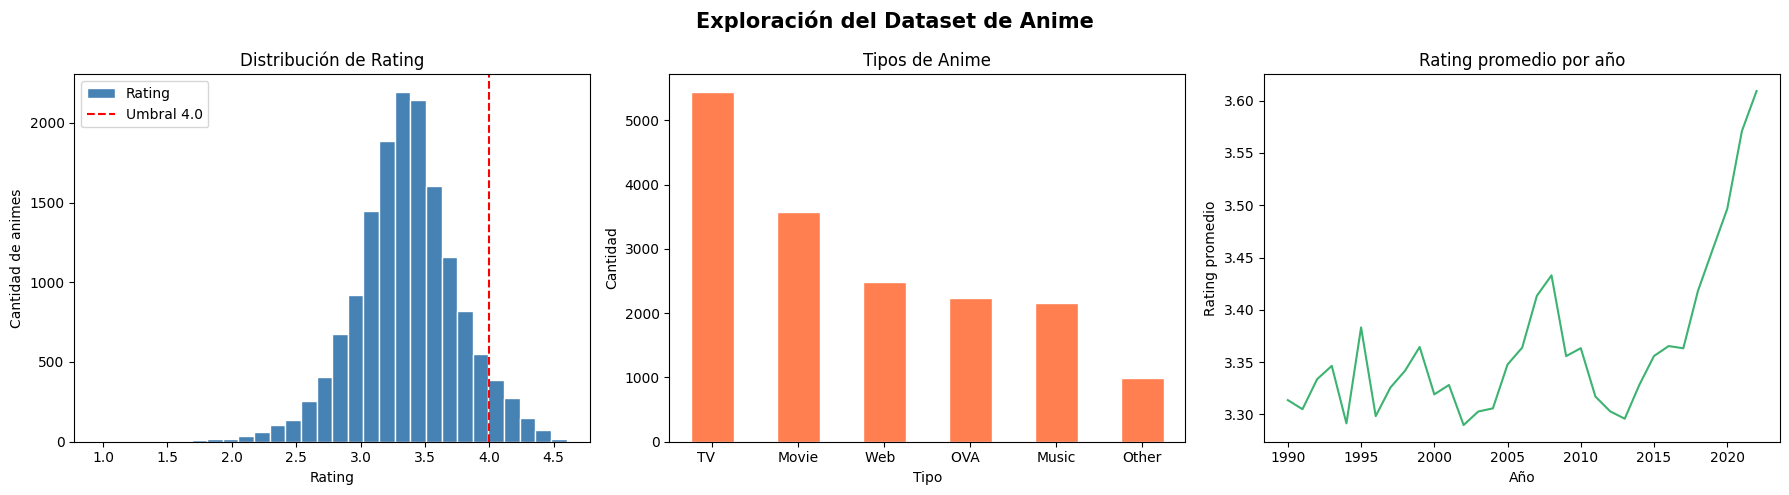

In [39]:
## ── Visualizaciones exploratorias ─────────────────────────────────────────
## Tres gráficas lado a lado para entender la distribución de los datos

fig, axes = plt.subplots(1, 3, figsize=(18, 5))   # crea una figura con 3 subplots en fila
fig.suptitle('Exploración del Dataset de Anime', fontsize=15, fontweight='bold')  # título general

## Gráfica 1: distribución del Rating
## Nos muestra si el dataset está balanceado o si hay muchos más animes buenos que malos
df['Rating'].dropna().plot(           # dropna() elimina nulos para no graficar NaN
    kind='hist',                      # tipo histograma: barras de frecuencia por rango de valor
    bins=30,                          # divide el rango en 30 intervalos
    ax=axes[0],                       # dibuja en el primer subplot
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('Distribución de Rating')     # título del subplot
axes[0].set_xlabel('Rating')                    # etiqueta eje X
axes[0].set_ylabel('Cantidad de animes')
axes[0].axvline(x=4.0, color='red', linestyle='--', label='Umbral 4.0')  # línea roja en el umbral de clasificación
axes[0].legend()

## Gráfica 2: distribución de tipos de anime
## Conecta con el EDA: saber que hay muchos más TV que Movies afecta cómo interpretamos los resultados
df['Type'].value_counts().head(6).plot(
    kind='bar',                       # barras verticales
    ax=axes[1],
    color='coral',
    edgecolor='white'
)
axes[1].set_title('Tipos de Anime')
axes[1].set_xlabel('Tipo')
axes[1].set_ylabel('Cantidad')
axes[1].tick_params(axis='x', rotation=0)   # rotación 0 para que las etiquetas sean legibles

## Gráfica 3: rating promedio por año de lanzamiento
## Muestra tendencias temporales: ¿los animes modernos tienen mejor rating?
(df.dropna(subset=['Release_year', 'Rating'])   # eliminamos filas donde falte el año o rating
   .groupby('Release_year')['Rating']           # agrupamos por año y tomamos la columna Rating
   .mean()                                      # calculamos el promedio de rating por año
   .loc[1990:]                                  # filtramos desde 1990 para evitar datos escasos
   .plot(ax=axes[2], color='mediumseagreen'))   # dibujamos la línea de tendencia
axes[2].set_title('Rating promedio por año')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Rating promedio')

plt.tight_layout()    # ajusta espaciado para que no se superpongan las gráficas
plt.show()

---
## 🧹 CELDA 5 — Limpieza y normalización de datos
Este paso convierte el dataset crudo en datos usables por los modelos.
La calidad de este paso determina la calidad de TODO lo que viene después.

**Pasos:**
1. Eliminar filas sin rating (no podemos entrenar sin etiqueta)
2. Crear la variable objetivo binaria (bien/mal valorado)
3. Limpiar el texto: minúsculas, sin puntuación, sin caracteres extraños
4. Combinar columnas de texto para darle más contexto al modelo

In [40]:
## ── Paso 1: eliminar filas sin rating ─────────────────────────────────────
## Sin rating no podemos crear la etiqueta → esas filas son inútiles para nuestro modelo
df_limpio = df.dropna(subset=['Rating']).copy()   # .copy() evita warnings de pandas sobre modificar copias
print(f'Filas con rating: {len(df_limpio):,} (eliminadas: {len(df) - len(df_limpio):,})')

## ── Paso 2: crear la variable objetivo (label) ────────────────────────────
## Convertimos el rating continuo (0.96-4.6) en una clasificación binaria:
## 1 = bien valorado (rating >= 4.0), 0 = mal valorado (rating < 4.0)
## Esto es necesario porque los modelos de clasificación esperan clases discretas
UMBRAL = 4.0                                      # punto de corte elegido según la distribución vista arriba
df_limpio['label'] = (df_limpio['Rating'] >= UMBRAL).astype(int)  # True→1, False→0
print(f'\nDistribución de clases:')
print(df_limpio['label'].value_counts())           # cuántos hay de cada clase
print(f'Balance: {df_limpio["label"].mean()*100:.1f}% bien valorados')  # porcentaje de clase positiva

## ── Paso 3: función de limpieza de texto ─────────────────────────────────
## Esta función se aplica a cada celda de texto del DataFrame
## La limpieza es CRÍTICA: caracteres raros, HTML, comillas sueltas confunden al tokenizador
def limpiar_texto(texto):
    # Verificamos que sea texto y no NaN; si es NaN devolvemos string vacío
    if not isinstance(texto, str):                 # isinstance verifica el tipo de la variable
        return ''                                   # devuelve cadena vacía para NaN o números
    texto = texto.lower()                          # convertimos a minúsculas → 'Action' == 'action'
    texto = re.sub(r"['\']", '', texto)            # eliminamos comillas simples que rodean descripciones
    texto = re.sub(r'[^a-z0-9\s,]', ' ', texto)   # eliminamos todo excepto letras, números, comas y espacios
    texto = re.sub(r'\s+', ' ', texto)             # reemplazamos múltiples espacios por uno solo
    return texto.strip()                           # strip() elimina espacios al inicio y fin

## ── Paso 4: crear texto combinado ────────────────────────────────────────
## Combinamos Name + Tags + Description en UN solo campo de texto por anime
## Esto da más información al modelo: el nombre, los géneros y el argumento a la vez
df_limpio['texto_tags'] = df_limpio['Tags'].apply(limpiar_texto)           # aplica la función a cada celda
df_limpio['texto_desc'] = df_limpio['Description'].apply(limpiar_texto)   # limpia la descripción
df_limpio['texto_nombre'] = df_limpio['Name'].apply(limpiar_texto)        # limpia el nombre

## El texto combinado une las tres partes con espacio; es lo que usan los modelos principales
df_limpio['texto_completo'] = (
    df_limpio['texto_nombre'] + ' ' +    # nombre del anime
    df_limpio['texto_tags']  + ' ' +    # tags/géneros del anime
    df_limpio['texto_desc']              # descripción del argumento
)

## Eliminamos filas donde el texto quedó vacío después de limpiar
df_limpio = df_limpio[df_limpio['texto_completo'].str.strip() != '']   # filtramos cadenas vacías

print(f'\nDataset limpio final: {len(df_limpio):,} filas')
print('\nEjemplo de texto limpio:')
print(df_limpio['texto_completo'].iloc[0][:200])   # mostramos los primeros 200 caracteres del primer ejemplo

Filas con rating: 15,364 (eliminadas: 3,131)

Distribución de clases:
label
0    14464
1      900
Name: count, dtype: int64
Balance: 5.9% bien valorados

Dataset limpio final: 15,364 filas

Ejemplo de texto limpio:
demon slayer kimetsu no yaiba entertainment district arc action, adventure, fantasy, shounen, demons, historical, martial arts, orphans, siblings, swordplay, based on a manga, explicit violence tanjir


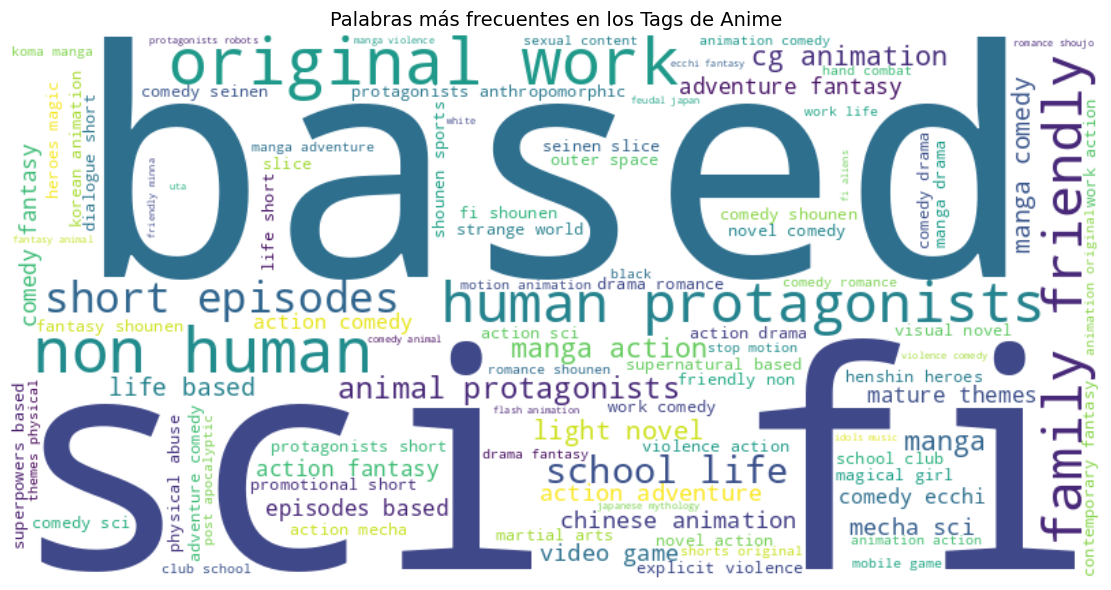

In [41]:
## ── Nube de palabras de los tags más frecuentes ───────────────────────────
## WordCloud nos muestra visualmente qué palabras aparecen más en los tags
## Conecta con vectorización: estas son las palabras que tendrán mayor peso en TF-IDF
todos_tags = ' '.join(df_limpio['texto_tags'].tolist())   # une todos los tags en un solo string gigante

wc = WordCloud(
    width=800, height=400,          # dimensiones de la imagen
    background_color='white',       # fondo blanco
    max_words=100,                  # máximo 100 palabras distintas
    colormap='viridis'             # paleta de colores
).generate(todos_tags)             # genera la nube a partir del texto

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')   # muestra la imagen; bilinear suaviza los bordes
plt.axis('off')                            # desactiva los ejes X e Y (no hacen falta para imágenes)
plt.title('Palabras más frecuentes en los Tags de Anime', fontsize=14)
plt.tight_layout()
plt.show()

---
## ✂️ CELDA 6 — División del dataset en train / test
Separamos los datos antes de cualquier modelado.
El set de test NO se toca hasta la evaluación final: simula datos del mundo real.

In [42]:
## Separamos el texto y la etiqueta en variables independientes
## X = características (lo que el modelo ve), y = etiqueta (lo que queremos predecir)
X = df_limpio['texto_completo'].values    # .values convierte la Serie de pandas a array de NumPy
y = df_limpio['label'].values             # array de 0s y 1s (0=mal valorado, 1=bien valorado)

## train_test_split divide X e y de forma sincronizada (cada X mantiene su y)
## test_size=0.20 → 20% para test, 80% para entrenamiento
## random_state=42 → semilla fija para que la división sea reproducible
## stratify=y → asegura que la proporción de clases sea igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,         # conecta con la evaluación final: 20% de datos nunca vistos
    random_state=42,        # reproducibilidad: con la misma semilla siempre obtenemos la misma división
    stratify=y              # mantiene balance de clases en ambos subsets
)

print(f'Tamaño train: {len(X_train):,} ejemplos')
print(f'Tamaño test:  {len(X_test):,} ejemplos')
print(f'Balance en train: {y_train.mean()*100:.1f}% positivos')
print(f'Balance en test:  {y_test.mean()*100:.1f}% positivos')

Tamaño train: 12,291 ejemplos
Tamaño test:  3,073 ejemplos
Balance en train: 5.9% positivos
Balance en test:  5.9% positivos


---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PARTE I — VECTORIZACIÓN
## ¿Qué es vectorización?
Es el proceso de convertir texto en números para que los algoritmos de ML puedan procesarlo.
El texto crudo no tiene valor matemático → necesitamos representarlo como un vector de números.

### Técnicas que veremos:
- **Bag of Words (BoW):** cuenta cuántas veces aparece cada palabra
- **TF-IDF:** pondera las palabras por su importancia relativa en el corpus

Ambas producen vectores **sparse** (dispersos): tienen miles de dimensiones pero la mayoría son cero.

In [43]:
## ═══════════════════════════════════════════════════════
##  VECTORIZACIÓN 1: Bag of Words (BoW)
##  Cuenta cuántas veces aparece cada palabra en el texto
##  Resultado: vector con una dimensión por palabra del vocabulario
## ═══════════════════════════════════════════════════════

## CountVectorizer construye el vocabulario con los datos de train
## y convierte cada texto en un vector de conteos
bow_vectorizer = CountVectorizer(
    max_features=5000,         # solo usa las 5000 palabras más frecuentes → controla el tamaño del vocabulario
    min_df=2,                  # ignora palabras que aparecen en menos de 2 documentos (typos, hapax)
    max_df=0.95,               # ignora palabras que aparecen en más del 95% de documentos (words sin información)
    ngram_range=(1, 2),        # incluye unigramas ('action') y bigramas ('demon slayer') → captura frases
    stop_words='english'       # elimina palabras comunes en inglés ('the', 'a', 'is') sin valor informativo
)

## fit_transform hace DOS cosas a la vez sobre el training set:
## 1. fit: aprende el vocabulario (qué palabras existen y cuál es su índice)
## 2. transform: convierte cada texto en su vector de conteos
## IMPORTANTE: solo hacemos fit sobre X_train, nunca sobre X_test (evitamos data leakage)
X_train_bow = bow_vectorizer.fit_transform(X_train)   # conecta: el vocabulario aprendido aquí se usa en la línea de abajo

## transform (sin fit) aplica el vocabulario YA aprendido al test set
## Palabras nuevas en test que no estaban en train se ignoran silenciosamente
X_test_bow  = bow_vectorizer.transform(X_test)       # conecta con X_train_bow: mismo vocabulario, diferentes textos

print(f'Shape matriz BoW train: {X_train_bow.shape}')   # (num_documentos, num_features)
print(f'Shape matriz BoW test:  {X_test_bow.shape}')

## Mostramos la densidad: qué porcentaje de celdas son NO cero
## Los vectores BoW son muy dispersos (sparse): la mayoría de palabras no aparecen en cada texto
densidad = X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]) * 100
print(f'Densidad de la matriz: {densidad:.3f}% (el resto son ceros)')

Shape matriz BoW train: (12291, 5000)
Shape matriz BoW test:  (3073, 5000)
Densidad de la matriz: 0.624% (el resto son ceros)


In [44]:
## ═══════════════════════════════════════════════════════
##  VECTORIZACIÓN 2: TF-IDF
##  TF = Term Frequency: qué tan frecuente es la palabra en ESE documento
##  IDF = Inverse Document Frequency: qué tan rara es la palabra en TODO el corpus
##  Palabras que aparecen en todos lados ('the') tienen IDF bajo → peso bajo
##  Palabras raras pero presentes ('swordplay') tienen IDF alto → peso alto
## ═══════════════════════════════════════════════════════

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,        # vocabulario más grande que BoW → captura más vocabulario específico de anime
    min_df=2,                  # misma lógica que en BoW: elimina palabras rarísimas
    max_df=0.90,               # más estricto que BoW: elimina palabras muy comunes
    ngram_range=(1, 3),        # incluye también trigramas: 'based on manga' es informativo
    sublinear_tf=True,         # aplica log(1+tf) en vez de tf: reduce el peso de repeticiones excesivas
    stop_words='english'       # elimina stop words igual que BoW
)

## Misma lógica: fit solo en train, transform en ambos
## Conecta con los modelos de ML de la siguiente celda: estos vectores son su input
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)   # aprende IDF + transforma train
X_test_tfidf  = tfidf_vectorizer.transform(X_test)        # aplica IDF aprendido a test

print(f'Shape matriz TF-IDF train: {X_train_tfidf.shape}')
print(f'Shape matriz TF-IDF test:  {X_test_tfidf.shape}')

## Comparación visual: BoW vs TF-IDF para una misma palabra
## Buscamos la palabra 'action' en ambos vocabularios para ver su índice
vocab_tfidf = tfidf_vectorizer.vocabulary_               # diccionario: palabra → índice de columna
print('\nAlgunas palabras y sus índices en TF-IDF:')
for palabra in ['action', 'romance', 'demon', 'school']:  # palabras comunes en anime
    if palabra in vocab_tfidf:
        print(f'  "{palabra}" → columna {vocab_tfidf[palabra]}')

Shape matriz TF-IDF train: (12291, 10000)
Shape matriz TF-IDF test:  (3073, 10000)

Algunas palabras y sus índices en TF-IDF:
  "action" → columna 156
  "romance" → columna 7284
  "demon" → columna 2144
  "school" → columna 7511


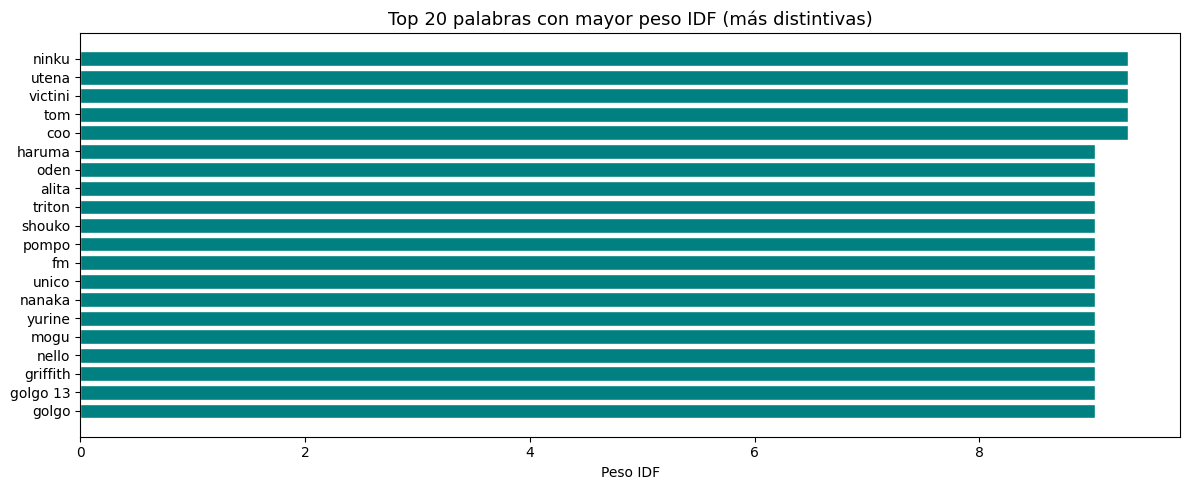

In [45]:
## ── Visualización: palabras con mayor peso TF-IDF ─────────────────────────
## Los pesos IDF nos dicen qué palabras son más DISTINTIVAS del corpus
## Palabras con IDF alto son raras → su presencia es muy informativa

## Obtenemos los nombres de las features (palabras) y sus pesos IDF
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())   # array de strings: cada posición = una palabra
idf_weights   = tfidf_vectorizer.idf_                                # array de floats: peso IDF de cada palabra

## Ordenamos de mayor a menor IDF y tomamos las top 20
top20_idx = np.argsort(idf_weights)[::-1][:20]   # argsort ordena indices; [::-1] invierte; [:20] toma primeros 20
top20_palabras = feature_names[top20_idx]         # palabras más distintas
top20_pesos    = idf_weights[top20_idx]           # sus pesos IDF

## Graficamos
plt.figure(figsize=(12, 5))
plt.barh(range(20), top20_pesos[::-1], color='teal', edgecolor='white')   # barras horizontales; [::-1] para que la más alta quede arriba
plt.yticks(range(20), top20_palabras[::-1], fontsize=10)                  # etiquetas del eje Y
plt.title('Top 20 palabras con mayor peso IDF (más distintivas)', fontsize=13)
plt.xlabel('Peso IDF')
plt.tight_layout()
plt.show()

In [46]:
## ═══════════════════════════════════════════════════════
##  MODELOS CLÁSICOS SOBRE TF-IDF
##  Usamos Regresión Logística y SVM para demostrar que
##  vectorización sola ya permite clasificar con buena accuracy
##  Esto es la línea de base (baseline) contra la que compararemos embeddings y transformers
## ═══════════════════════════════════════════════════════

resultados = {}    # diccionario para guardar accuracy de todos los modelos (lo usamos al final para comparar)

## ── Modelo 1: Regresión Logística ─────────────────────────────────────────
## Modelo lineal: aprende un peso por feature TF-IDF
## Si el peso de 'romance' es alto, los animes con esa tag tienden a tener buen rating
lr = LogisticRegression(
    max_iter=1000,    # iteraciones máximas del optimizador antes de rendirse
    C=1.0,            # regularización: C grande = menos regularización, el modelo puede ajustarse más
    random_state=42   # reproducibilidad
)
lr.fit(X_train_tfidf, y_train)              # fit: aprende los pesos mirando los vectores TF-IDF y las etiquetas
y_pred_lr = lr.predict(X_test_tfidf)       # predict: aplica los pesos aprendidos a los vectores de test
acc_lr = accuracy_score(y_test, y_pred_lr) # compara predicciones con etiquetas reales
resultados['LogReg + TF-IDF'] = acc_lr     # guardamos para comparación final

print('=== REGRESIÓN LOGÍSTICA + TF-IDF ===')
print(f'Accuracy: {acc_lr:.4f} ({acc_lr*100:.1f}%)')
## classification_report imprime precision, recall y F1 para cada clase
## precision: de los que predije positivos, ¿cuántos lo eran?
## recall: de todos los positivos reales, ¿cuántos encontré?
## F1: media armónica de precision y recall
print(classification_report(y_test, y_pred_lr, target_names=['Mal valorado', 'Bien valorado']))

## ── Modelo 2: SVM Lineal ──────────────────────────────────────────────────
## LinearSVC encuentra el hiperplano que maximiza el margen entre clases
## Es muy eficiente con vectores TF-IDF de alta dimensión
svm = LinearSVC(
    C=1.0,           # parámetro de penalización: controla el trade-off entre margen y errores
    max_iter=2000,   # más iteraciones que LR porque SVM converge más lento
    random_state=42
)
svm.fit(X_train_tfidf, y_train)             # fit: aprende el hiperplano separador
y_pred_svm = svm.predict(X_test_tfidf)     # predict: clasifica cada vector según qué lado del hiperplano cae
acc_svm = accuracy_score(y_test, y_pred_svm)
resultados['SVM + TF-IDF'] = acc_svm

print('\n=== SVM LINEAL + TF-IDF ===')
print(f'Accuracy: {acc_svm:.4f} ({acc_svm*100:.1f}%)')
print(classification_report(y_test, y_pred_svm, target_names=['Mal valorado', 'Bien valorado']))

=== REGRESIÓN LOGÍSTICA + TF-IDF ===
Accuracy: 0.9440 (94.4%)
               precision    recall  f1-score   support

 Mal valorado       0.94      1.00      0.97      2893
Bien valorado       0.79      0.06      0.11       180

     accuracy                           0.94      3073
    macro avg       0.87      0.53      0.54      3073
 weighted avg       0.94      0.94      0.92      3073


=== SVM LINEAL + TF-IDF ===
Accuracy: 0.9518 (95.2%)
               precision    recall  f1-score   support

 Mal valorado       0.96      0.99      0.97      2893
Bien valorado       0.67      0.34      0.46       180

     accuracy                           0.95      3073
    macro avg       0.82      0.67      0.72      3073
 weighted avg       0.94      0.95      0.94      3073



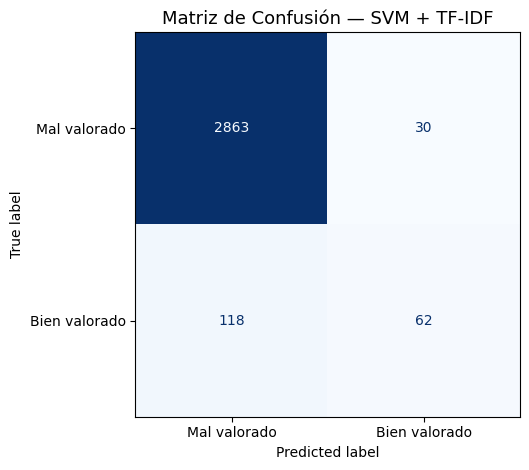

In [47]:
## ── Matriz de confusión del mejor modelo clásico ──────────────────────────
## La matriz de confusión muestra VP, FP, FN, VN de forma visual
## VP (abajo-derecha): predije bien y era bien → correcto
## FP (arriba-derecha): predije bien pero era mal → falsa alarma
## FN (abajo-izquierda): predije mal pero era bien → me lo perdí
## VN (arriba-izquierda): predije mal y era mal → correcto

cm = confusion_matrix(y_test, y_pred_svm)              # calcula la matriz con etiquetas reales vs predichas
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,                               # le pasamos la matriz calculada
    display_labels=['Mal valorado', 'Bien valorado']   # etiquetas legibles para los ejes
)
disp.plot(cmap='Blues', colorbar=False)                # cmap='Blues': escala de azul, más azul = más cantidad
plt.title('Matriz de Confusión — SVM + TF-IDF', fontsize=13)
plt.tight_layout()
plt.show()

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PARTE II — EMBEDDINGS
## ¿Qué son los embeddings?
Los vectores TF-IDF tienen miles de dimensiones y no capturan significado semántico:
'good' y 'great' son palabras completamente independientes en TF-IDF.

Los **embeddings** son vectores **densos** (pocas dimensiones, típicamente 32-300) **entrenables**.
Se aprenden durante el entrenamiento para que palabras similares queden cerca en el espacio vectorial.

### ¿Cómo funciona la capa Embedding en Keras?
Es una matriz `W` de shape `(vocab_size, embed_dim)`. Cada fila es el vector de una palabra.
Dado el índice de una palabra, se extrae su fila: eso es **indexar un embedding**.

In [48]:
## ═══════════════════════════════════════════════════════
##  PREPARACIÓN PARA EMBEDDINGS
##  El Tokenizer de Keras hace lo mismo que CountVectorizer
##  PERO en vez de vectores de conteos, produce SECUENCIAS de índices
##  Ejemplo: 'action adventure' → [3, 7] (índices de cada palabra en el vocabulario)
## ═══════════════════════════════════════════════════════

VOCAB_SIZE  = 15000    # tamaño del vocabulario: cuántas palabras únicas consideramos
MAX_LEN     = 150      # longitud máxima de cada secuencia después del padding
EMBED_DIM   = 64       # dimensión de cada vector de embedding (cada palabra = vector de 64 números)

## Tokenizer construye el vocabulario y asigna un índice entero a cada palabra
## num_words=VOCAB_SIZE: solo guarda las VOCAB_SIZE palabras más frecuentes
## oov_token='<OOV>': palabras fuera del vocabulario (out-of-vocabulary) reciben el índice 1
tokenizer_emb = Tokenizer(
    num_words=VOCAB_SIZE,     # conecta con VOCAB_SIZE: limita el vocabulario
    oov_token='<OOV>',        # manejo de palabras desconocidas en test
    lower=True                # convierte a minúsculas automáticamente
)

## fit_on_texts construye el vocabulario leyendo TODOS los textos de train
## Crea internamente: word_index (dict: palabra→índice), word_counts (dict: palabra→frecuencia)
tokenizer_emb.fit_on_texts(X_train)    # SOLO sobre train: evitamos que el modelo vea vocabulario de test

print(f'Vocabulario aprendido: {len(tokenizer_emb.word_index):,} palabras únicas')
print(f'Usando las top: {VOCAB_SIZE:,}')

## Palabras más frecuentes del vocabulario aprendido
palabras_freq = sorted(tokenizer_emb.word_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print('\nTop 10 palabras más frecuentes:')
for p, c in palabras_freq:
    print(f'  {p}: {c:,} veces')

Vocabulario aprendido: 36,614 palabras únicas
Usando las top: 15,000

Top 10 palabras más frecuentes:
  the: 34,940 veces
  a: 23,010 veces
  to: 17,478 veces
  and: 17,073 veces
  of: 15,625 veces
  on: 8,828 veces
  in: 8,560 veces
  no: 8,115 veces
  is: 7,679 veces
  his: 5,855 veces


In [49]:
## ── Convertir textos a secuencias e igualar longitudes ────────────────────
## texts_to_sequences convierte cada texto en una lista de índices enteros
## Ejemplo: 'action adventure demons' → [3, 7, 142]
## Conecta con la capa Embedding: esos índices se usan para hacer lookup en la matriz W

## Convertimos texto a secuencias de índices
X_train_seq = tokenizer_emb.texts_to_sequences(X_train)   # lista de listas: [[3,7,142,...], [5,2,...], ...]
X_test_seq  = tokenizer_emb.texts_to_sequences(X_test)    # aplica el mismo vocabulario a test

## Mostramos cómo se ve una secuencia para entender la transformación
print('Texto original (primeros 100 chars):')
print(X_train[0][:100])
print('\nSecuencia de índices (primeros 15):')
print(X_train_seq[0][:15])       # imprime los primeros 15 índices de la primera secuencia

## Las secuencias tienen distintas longitudes (reseñas largas vs cortas)
## pad_sequences las iguala a MAX_LEN:
## - Si es más corta: rellena con 0 (PAD) al inicio (padding='pre')
## - Si es más larga: recorta por el final (truncating='post')
## padding='pre' + LSTM = el último token que ve el modelo es el último token real (mejor que 'post')
X_train_pad = pad_sequences(
    X_train_seq,              # lista de secuencias de longitudes variables
    maxlen=MAX_LEN,           # longitud objetivo: todas quedan con 150 posiciones
    padding='pre',            # ceros al inicio → el texto real está al final de la secuencia
    truncating='post'         # si es larga, corta por el final
)
X_test_pad = pad_sequences(   # mismos parámetros para mantener consistencia con train
    X_test_seq,
    maxlen=MAX_LEN,
    padding='pre',
    truncating='post'
)

print(f'\nShape después del padding:')
print(f'Train: {X_train_pad.shape}')    # (num_ejemplos, MAX_LEN)
print(f'Test:  {X_test_pad.shape}')

Texto original (primeros 100 chars):
shiratori reiko de gozaimasu comedy, romance, based on a manga 19 year old reiko is a rich, arrogant

Secuencia de índices (primeros 15):
[8356, 3221, 665, 1, 27, 78, 12, 7, 3, 25, 4585, 130, 158, 3221, 10]

Shape después del padding:
Train: (12291, 150)
Test:  (3073, 150)


In [50]:
## ═══════════════════════════════════════════════════════
##  MODELO CON EMBEDDING ENTRENABLE
##  Arquitectura: Embedding → GlobalAveragePooling → Dense → Dense
##
##  Embedding: convierte cada índice en un vector de EMBED_DIM dimensiones
##  GlobalAveragePooling1D: promedia los vectores de todos los tokens → 1 vector por documento
##  Dense: capas de clasificación que aprenden a separar positivos de negativos
## ═══════════════════════════════════════════════════════

modelo_emb = Sequential([     # Sequential = capas apiladas en orden; salida de una es entrada de la siguiente

    ## Capa 1: Embedding
    ## Crea la matriz W de shape (VOCAB_SIZE, EMBED_DIM)
    ## input_length=MAX_LEN es redundante en TF2 pero documenta la forma esperada
    Embedding(
        input_dim=VOCAB_SIZE,      # filas de la matriz: una por palabra del vocabulario
        output_dim=EMBED_DIM,      # columnas: dimensión del vector de embedding
        input_length=MAX_LEN,      # documenta que cada secuencia tiene MAX_LEN tokens
        name='embedding_layer'     # nombre para identificar esta capa en model.summary()
    ),
    ## Salida de Embedding: (batch, MAX_LEN, EMBED_DIM) → cada token tiene su vector

    ## Capa 2: GlobalAveragePooling1D
    ## Promedia los EMBED_DIM vectores de los MAX_LEN tokens
    ## Transforma (batch, MAX_LEN, EMBED_DIM) → (batch, EMBED_DIM)
    ## Alternativa: Flatten() o LSTM() — Average es más rápido y funciona bien para texto corto
    GlobalAveragePooling1D(name='pooling_layer'),
    ## Salida: (batch, EMBED_DIM) → UN vector por documento

    ## Capa 3: Dense oculta
    ## relu: rectified linear unit → f(x) = max(0, x). Introduce no-linealidad sin saturarse
    Dense(128, activation='relu', name='dense_1'),

    ## Capa 4: Dropout — apaga 30% de neuronas aleatoriamente durante training
    ## Fuerza al modelo a no depender de pocas neuronas → reduce overfitting
    ## En inferencia (predict) Dropout se desactiva automáticamente
    Dropout(0.30, name='dropout_1'),

    ## Capa 5: Dense final de clasificación
    ## 1 neurona + sigmoid → probabilidad en (0, 1) de que el anime sea bien valorado
    Dense(1, activation='sigmoid', name='salida')
])

## Compilamos el modelo: definimos el optimizador, la función de pérdida y las métricas
modelo_emb.compile(
    optimizer='adam',                   # Adam: optimizador adaptativo, estándar para NLP
    loss='binary_crossentropy',         # pérdida para clasificación binaria con sigmoid
    metrics=['accuracy']               # métricas que se imprimen durante el entrenamiento
)

## summary() imprime arquitectura, shapes de cada capa y número de parámetros
modelo_emb.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_layer (Embedding)     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
## ── Entrenamiento del modelo de embeddings ────────────────────────────────
## model.fit ejecuta el ciclo completo de entrenamiento:
## por cada época: forward pass → pérdida → backward pass → actualización Adam

## EarlyStopping detiene el entrenamiento si val_loss no mejora por 'patience' épocas
## Esto previene overfitting automáticamente sin necesidad de fijar el número exacto de épocas
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # observa la pérdida en validación (no en train)
    patience=3,               # para si en 3 épocas consecutivas val_loss no mejora
    restore_best_weights=True # al parar, restaura los pesos de la mejor época (no la última)
)

## ReduceLROnPlateau baja el learning rate si val_loss se estanca
## Un learning rate más pequeño permite ajustes más finos cuando ya estamos cerca del mínimo
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',   # también monitorea val_loss
    factor=0.5,           # multiplica el lr por 0.5 (lo divide a la mitad)
    patience=2,           # espera 2 épocas antes de bajar el lr
    min_lr=1e-6           # lr mínimo para no bajarlo infinitamente
)

## Entrenamos
historial_emb = modelo_emb.fit(
    X_train_pad, y_train,           # datos de entrada y etiquetas de entrenamiento
    epochs=20,                      # máximo de épocas; EarlyStopping puede parar antes
    batch_size=128,                 # 128 ejemplos por actualización de pesos
    validation_split=0.15,          # usa 15% de train como validación interna
    callbacks=[early_stop, reduce_lr],  # aplica los dos callbacks durante el entrenamiento
    verbose=1                       # imprime barra de progreso por época
)

print(f'\nEntrenamiento terminado en {len(historial_emb.history["loss"])} épocas')

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9367 - loss: 0.2445 - val_accuracy: 0.9458 - val_loss: 0.1971 - learning_rate: 0.0010
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9407 - loss: 0.2092 - val_accuracy: 0.9458 - val_loss: 0.1922 - learning_rate: 0.0010
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9407 - loss: 0.2044 - val_accuracy: 0.9458 - val_loss: 0.1891 - learning_rate: 0.0010
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9407 - loss: 0.1978 - val_accuracy: 0.9458 - val_loss: 0.1842 - learning_rate: 0.0010
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9407 - loss: 0.1857 - val_accuracy: 0.9458 - val_loss: 0.1747 - learning_rate: 0.0010
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9410 - loss: 0.1649 - val_accuracy: 0.9458 - val_loss: 0.1580 - learning_rate: 0.0010
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9478 - loss: 0.1356 - val_ac

Accuracy en test (Embedding): 0.9509 (95.1%)


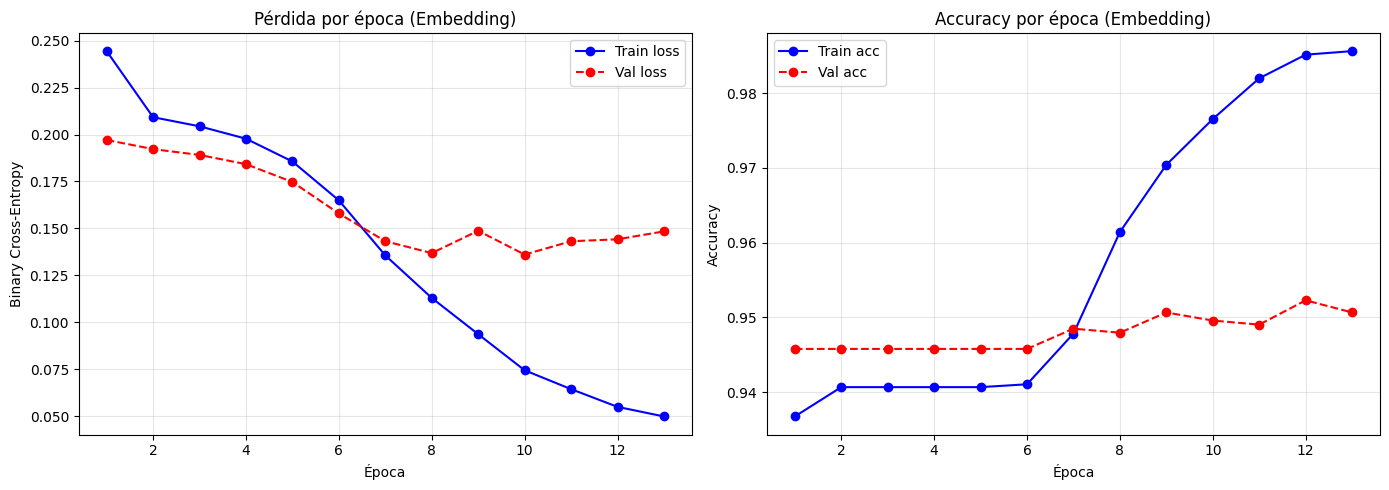

In [52]:
## ── Evaluación y visualización del modelo de embeddings ───────────────────
## Evaluamos en el test set para ver el rendimiento en datos completamente nuevos

loss_emb, acc_emb = modelo_emb.evaluate(
    X_test_pad, y_test,     # datos de test: nunca los vio durante el entrenamiento
    verbose=0               # silenciamos la salida de evaluate para limpiar el output
)
resultados['Embedding + Dense'] = acc_emb   # guardamos para comparación final

print(f'Accuracy en test (Embedding): {acc_emb:.4f} ({acc_emb*100:.1f}%)')

## ── Gráficas de entrenamiento ─────────────────────────────────────────────
## Las curvas de loss y accuracy nos dicen si el modelo aprendió bien o se sobreajustó

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, len(historial_emb.history['loss']) + 1)   # eje X: 1, 2, 3, ..., N épocas

## Gráfica 1: curvas de pérdida
## Si val_loss sube mientras loss baja → overfitting
## Si ambas bajan en paralelo → el modelo generaliza bien
axes[0].plot(epocas, historial_emb.history['loss'], 'b-o', label='Train loss')        # 'b-o' = línea azul con puntos
axes[0].plot(epocas, historial_emb.history['val_loss'], 'r--o', label='Val loss')    # 'r--o' = línea roja punteada
axes[0].set_title('Pérdida por época (Embedding)')                                   # título del subplot
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()                                                                      # muestra leyenda de colores
axes[0].grid(alpha=0.3)                                                               # grilla suave de fondo

## Gráfica 2: curvas de accuracy
axes[1].plot(epocas, historial_emb.history['accuracy'],     'b-o', label='Train acc')
axes[1].plot(epocas, historial_emb.history['val_accuracy'], 'r--o', label='Val acc')
axes[1].set_title('Accuracy por época (Embedding)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

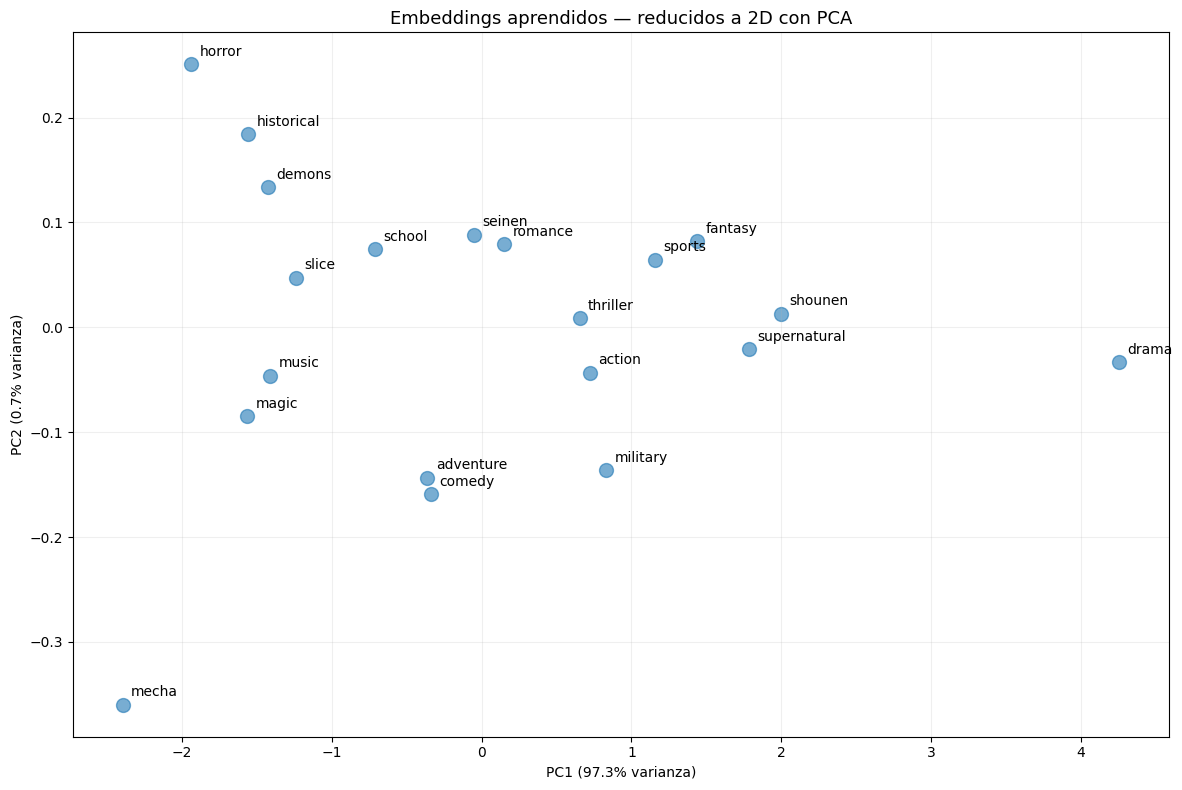

In [53]:
## ── Visualización de los embeddings aprendidos ────────────────────────────
## Reducimos los vectores de 64 dimensiones a 2D con PCA para poder graficarlos
## Si el modelo aprendió bien, palabras similares deben estar cerca en 2D

from sklearn.decomposition import PCA    # Análisis de Componentes Principales: reduce dimensionalidad

## Extraemos la matriz de embeddings aprendida durante el entrenamiento
## .get_layer() recupera una capa por nombre; .get_weights()[0] devuelve la matriz W
pesos_emb = modelo_emb.get_layer('embedding_layer').get_weights()[0]   # shape: (VOCAB_SIZE, EMBED_DIM)

## Seleccionamos palabras interesantes del vocabulario de anime para visualizar
palabras_viz = [
    'action', 'romance', 'comedy', 'horror', 'fantasy', 'adventure',
    'school', 'magic', 'demons', 'supernatural', 'thriller', 'drama',
    'shounen', 'seinen', 'mecha', 'sports', 'music', 'slice',
    'historical', 'military'
]

## Para cada palabra, buscamos su índice en el vocabulario y extraemos su vector
word_index = tokenizer_emb.word_index     # diccionario: palabra → índice
vectores_sel = []                          # lista de vectores de las palabras seleccionadas
etiquetas_sel = []                         # sus nombres correspondientes

for p in palabras_viz:
    if p in word_index and word_index[p] < VOCAB_SIZE:    # verificamos que esté en el vocabulario
        idx = word_index[p]                                # obtenemos el índice
        vectores_sel.append(pesos_emb[idx])               # extraemos la fila idx de la matriz W
        etiquetas_sel.append(p)                           # guardamos el nombre de la palabra

## PCA reduce de EMBED_DIM (64) dimensiones a 2 para poder graficar
## Las 2 nuevas dimensiones capturan la mayor varianza del espacio original
pca = PCA(n_components=2)                             # creamos PCA que reduce a 2 componentes
coords_2d = pca.fit_transform(np.array(vectores_sel)) # aplica PCA y devuelve coordenadas 2D

## Graficamos cada palabra como un punto en el espacio 2D
plt.figure(figsize=(12, 8))
plt.scatter(
    coords_2d[:, 0],    # coordenada X (primer componente principal)
    coords_2d[:, 1],    # coordenada Y (segundo componente principal)
    alpha=0.6,          # transparencia para ver puntos superpuestos
    s=100               # tamaño de cada punto
)

## Añadimos etiquetas a cada punto
for i, label in enumerate(etiquetas_sel):
    plt.annotate(
        label,                      # texto de la etiqueta
        (coords_2d[i, 0], coords_2d[i, 1]),   # posición: coordenadas del punto
        textcoords='offset points', # las coordenadas del texto son relativas al punto
        xytext=(6, 6),              # desplazamiento del texto: 6px a la derecha y arriba del punto
        fontsize=10
    )

plt.title('Embeddings aprendidos — reducidos a 2D con PCA', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')   # cuánta varianza explica PC1
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')   # cuánta varianza explica PC2
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PARTE III — TRANSFORMERS
## ¿Qué es un Transformer?
Es la arquitectura de NLP más poderosa actual. A diferencia de LSTM (procesa token por token),
el Transformer procesa **toda la secuencia en paralelo** usando **mecanismos de atención**.

Usamos **DistilBERT**: versión destilada de BERT (40% menos parámetros, 60% más rápido, 97% del rendimiento).
Ya fue preentrenado con millones de textos en inglés, así que ya "entiende" el idioma.
Solo hacemos **fine-tuning**: ajustamos sus pesos a nuestra tarea específica (clasificar animes).

### Ventaja clave de los Transformers:
El mismo texto 'great' puede tener un embedding diferente según el contexto:
- 'not great' → el embedding de 'great' captura la negación
- 'absolutely great' → el embedding captura el énfasis positivo

TF-IDF y los embeddings simples NO pueden hacer esto.

In [54]:
## ═══════════════════════════════════════════════════════
##  PREPARACIÓN PARA TRANSFORMERS
##  1. Usamos un subconjunto del dataset (Transformers son lentos de entrenar)
##  2. Tokenizamos con el tokenizador de DistilBERT (WordPiece)
##  3. Creamos un Dataset de PyTorch
## ═══════════════════════════════════════════════════════

## Usamos solo los tags (más corto que descripción completa) para acelerar el entrenamiento
## En un proyecto real usaríamos texto completo pero en Colab el tiempo es limitado
X_train_transformer = df_limpio['texto_tags'].values[   # tomamos la columna de tags del dataset limpio
    :len(y_train)                                        # alineamos con y_train (mismo número de filas)
]
X_test_transformer  = df_limpio['texto_tags'].values[
    len(y_train):len(y_train)+len(y_test)               # las filas siguientes son el test
]

## Cargamos el tokenizador de DistilBERT desde HuggingFace
## AutoTokenizer detecta automáticamente el tipo de tokenizador según el nombre del modelo
## DistilBERT usa WordPiece: divide palabras raras en sub-palabras ('swordplay' → ['sword', '##play'])
MODELO_NOMBRE = 'distilbert-base-uncased'    # 'uncased' = no distingue mayúsculas/minúsculas
tokenizer_bert = AutoTokenizer.from_pretrained(
    MODELO_NOMBRE                            # descarga el tokenizador del modelo especificado
)

print(f'Tokenizador cargado: {MODELO_NOMBRE}')
print(f'Vocabulario del tokenizador: {tokenizer_bert.vocab_size:,} tokens')

## Mostramos cómo tokeniza DistilBERT un texto de anime
## Notamos que agrega tokens especiales: [CLS] al inicio y [SEP] al final
## [CLS] es el token que BERT usa para clasificación: su embedding representa la secuencia completa
ejemplo = 'Action Adventure Fantasy Shounen Demons'
tokens = tokenizer_bert.tokenize(ejemplo)   # tokenize devuelve los sub-tokens como strings
print(f'\nEjemplo: "{ejemplo}"')
print(f'Tokens: {tokens}')
print(f'IDs: {tokenizer_bert.encode(ejemplo)}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizador cargado: distilbert-base-uncased
Vocabulario del tokenizador: 30,522 tokens

Ejemplo: "Action Adventure Fantasy Shounen Demons"
Tokens: ['action', 'adventure', 'fantasy', 'sho', '##une', '##n', 'demons']
IDs: [101, 2895, 6172, 5913, 26822, 9816, 2078, 7942, 102]


In [55]:
## ── Tokenización del dataset completo ─────────────────────────────────────
## batch_encode_plus procesa múltiples textos a la vez de forma eficiente
## Produce tres cosas por texto:
##   input_ids: índices de los tokens (equivalente al padding de Keras)
##   attention_mask: 1 para tokens reales, 0 para padding → BERT ignora los 0s

MAX_LEN_BERT = 64    # DistilBERT acepta hasta 512 tokens; 64 es suficiente para los tags

## Tokenizamos el set de entrenamiento
train_encodings = tokenizer_bert(
    X_train_transformer.tolist(),   # .tolist() convierte array NumPy a lista Python
    truncation=True,                # si el texto es más largo que MAX_LEN_BERT, lo recorta
    padding='max_length',           # rellena hasta MAX_LEN_BERT con [PAD] tokens
    max_length=MAX_LEN_BERT,        # longitud fija para todos los textos
    return_tensors='pt'             # devuelve tensores de PyTorch (no listas)
)

## Tokenizamos el set de test con los mismos parámetros
test_encodings = tokenizer_bert(
    X_test_transformer.tolist(),
    truncation=True,
    padding='max_length',
    max_length=MAX_LEN_BERT,
    return_tensors='pt'
)

print(f'Shape input_ids train: {train_encodings["input_ids"].shape}')   # (N, MAX_LEN_BERT)
print(f'Shape input_ids test:  {test_encodings["input_ids"].shape}')
print(f'\nEjemplo input_ids (primeros 10): {train_encodings["input_ids"][0][:10]}')
print(f'Ejemplo attention_mask (primeros 10): {train_encodings["attention_mask"][0][:10]}')

Shape input_ids train: torch.Size([12291, 64])
Shape input_ids test:  torch.Size([3073, 64])

Ejemplo input_ids (primeros 10): tensor([  101,  2895,  1010,  6172,  1010,  5913,  1010, 26822,  9816,  2078])
Ejemplo attention_mask (primeros 10): tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [56]:
## ── Clase Dataset de PyTorch ──────────────────────────────────────────────
## El Trainer de HuggingFace necesita un objeto Dataset para leer los datos en batches
## Heredamos de torch.utils.data.Dataset e implementamos 3 métodos obligatorios:
##   __len__: cuántos ejemplos hay
##   __getitem__: devuelve el ejemplo i-ésimo

class AnimeDataset(Dataset):    # hereda de Dataset → obliga a implementar los métodos de abajo

    def __init__(self, encodings, labels):
        ## encodings: output del tokenizador (input_ids + attention_mask)
        ## labels: array de 0s y 1s (etiquetas de clasificación)
        self.encodings = encodings                               # guardamos las tokenizaciones
        self.labels    = torch.tensor(labels, dtype=torch.long) # convertimos a tensor de PyTorch (long = enteros)

    def __len__(self):
        ## El Trainer llama a len() para saber cuántos ejemplos tiene el dataset
        return len(self.labels)    # devuelve el número de ejemplos

    def __getitem__(self, idx):
        ## El Trainer llama a dataset[idx] para obtener el ejemplo idx
        ## Devolvemos un diccionario con input_ids, attention_mask y labels
        return {
            'input_ids':      self.encodings['input_ids'][idx],       # tensor de índices de tokens
            'attention_mask': self.encodings['attention_mask'][idx],  # tensor de máscara de atención
            'labels':         self.labels[idx]                        # etiqueta: 0 o 1
        }

## Creamos los datasets de entrenamiento y evaluación
train_dataset = AnimeDataset(train_encodings, y_train)   # conecta con train_encodings y y_train de arriba
test_dataset  = AnimeDataset(test_encodings,  y_test)    # conecta con test_encodings y y_test

print(f'Dataset train: {len(train_dataset):,} ejemplos')
print(f'Dataset test:  {len(test_dataset):,} ejemplos')

## Verificamos la estructura de un ejemplo
ejemplo0 = train_dataset[0]   # accedemos al primer ejemplo
print(f'\nEjemplo 0:')
for k, v in ejemplo0.items():
    print(f'  {k}: shape={v.shape}, dtype={v.dtype}')

Dataset train: 12,291 ejemplos
Dataset test:  3,073 ejemplos

Ejemplo 0:
  input_ids: shape=torch.Size([64]), dtype=torch.int64
  attention_mask: shape=torch.Size([64]), dtype=torch.int64
  labels: shape=torch.Size([]), dtype=torch.int64


In [63]:
## ── Carga del modelo preentrenado DistilBERT ──────────────────────────────
## AutoModelForSequenceClassification carga DistilBERT con una cabeza de clasificación
## La cabeza es una capa Dense(num_labels) que se agrega sobre el [CLS] embedding
## num_labels=2 → clasificación binaria (bien valorado / mal valorado)

modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    MODELO_NOMBRE,    # descarga DistilBERT preentrenado (~250MB de pesos)
    num_labels=2      # define que la cabeza de clasificación tiene 2 neuronas de salida
)

## Contamos los parámetros del modelo
total_params = sum(p.numel() for p in modelo_bert.parameters())              # .numel() = número de elementos
params_entrenables = sum(p.numel() for p in modelo_bert.parameters() if p.requires_grad)  # solo los entrenables
print(f'Parámetros totales: {total_params:,}')
print(f'Parámetros entrenables: {params_entrenables:,}')

## Configuramos el entrenamiento con TrainingArguments
## Todos los hiperparámetros del entrenamiento van aquí
from transformers import IntervalStrategy # Importamos IntervalStrategy para usar en TrainingArguments
training_args = TrainingArguments(
    output_dir='./resultados_bert',        # directorio donde se guardan checkpoints y logs
    num_train_epochs=3,                    # épocas: con 3 es suficiente para fine-tuning
    per_device_train_batch_size=32,        # batch size de entrenamiento por GPU
    per_device_eval_batch_size=64,         # batch size de evaluación (puede ser mayor, no calcula gradientes)
    warmup_steps=100,                      # pasos iniciales con learning rate bajo para estabilizar
    weight_decay=0.01,                     # regularización L2: penaliza pesos grandes
    logging_dir='./logs',                  # directorio para logs de TensorBoard
    logging_steps=50,                      # loguea métricas cada 50 pasos
    # evaluation_strategy=IntervalStrategy.EPOCH, # evalúa en el set de evaluación al final de cada época
    # save_strategy=IntervalStrategy.EPOCH,                 # guarda checkpoint al final de cada época
    # load_best_model_at_end=True,           # al terminar, carga los pesos de la mejor época
    # metric_for_best_model='eval_loss',     # usa eval_loss para decidir cuál fue la mejor época
    report_to='none',                      # desactiva WandB/MLflow (no los tenemos configurados)
    fp16=True                              # usa float16 en vez de float32 → duplica velocidad en GPU
)

print('TrainingArguments configurados correctamente')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Parámetros totales: 66,955,010
Parámetros entrenables: 66,955,010
TrainingArguments configurados correctamente


In [64]:
## ── Función de métricas para el Trainer ──────────────────────────────────
## El Trainer llama a esta función al final de cada época para calcular las métricas
## eval_pred es un named tuple con (predictions, label_ids)

def calcular_metricas(eval_pred):
    logits, labels = eval_pred            # logits: salida cruda del modelo antes de softmax
    predicciones = np.argmax(logits, axis=-1)   # argmax sobre las 2 clases → 0 o 1
    acc = accuracy_score(labels, predicciones)  # accuracy: fracción de predicciones correctas
    return {'accuracy': acc}              # el Trainer loguea y guarda este diccionario

## ── Crear el Trainer ─────────────────────────────────────────────────────
## Trainer encapsula todo el ciclo de entrenamiento:
## forward pass, cálculo de pérdida, backward pass, actualización de pesos, evaluación
trainer = Trainer(
    model=modelo_bert,                  # el modelo DistilBERT con cabeza de clasificación
    args=training_args,                 # hiperparámetros de entrenamiento definidos arriba
    train_dataset=train_dataset,        # dataset de entrenamiento (PyTorch Dataset)
    eval_dataset=test_dataset,          # dataset de evaluación (PyTorch Dataset)
    compute_metrics=calcular_metricas   # función para calcular accuracy en cada evaluación
)

print('Trainer listo. Iniciando fine-tuning de DistilBERT...')
print('⚠️  Asegurate de tener GPU habilitada en Colab: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU')

## ── Entrenamiento (fine-tuning) ───────────────────────────────────────────
## trainer.train() ejecuta el ciclo completo de fine-tuning
## Al final carga automáticamente los pesos de la mejor época (load_best_model_at_end=True)
train_result = trainer.train()   # conecta todo: modelo, datos, argumentos, métricas

print(f'\nFine-tuning completado')
print(f'Pasos totales: {train_result.global_step}')
print(f'Loss final de entrenamiento: {train_result.training_loss:.4f}')

Trainer listo. Iniciando fine-tuning de DistilBERT...
⚠️  Asegurate de tener GPU habilitada en Colab: Entorno de ejecución → Cambiar tipo de entorno → T4 GPU


Step,Training Loss
50,0.375373
100,0.272230
150,0.205945
200,0.255431
250,0.230315
300,0.216788
350,0.216733
400,0.193949
450,0.247616
500,0.244746


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fine-tuning completado
Pasos totales: 1155
Loss final de entrenamiento: 0.2321


In [65]:
## ── Evaluación final del Transformer ─────────────────────────────────────
## trainer.evaluate() corre el modelo sobre el test set y calcula las métricas

metricas_bert = trainer.evaluate()   # devuelve diccionario con eval_loss, eval_accuracy, etc.
acc_bert = metricas_bert['eval_accuracy']   # extraemos el accuracy
resultados['DistilBERT (Transformer)'] = acc_bert    ## guardamos para comparación final

print('=== EVALUACIÓN DISTILBERT ===')
for k, v in metricas_bert.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')   # imprimimos solo los valores numéricos con 4 decimales

## ── Predicciones con confianza ────────────────────────────────────────────
## trainer.predict() devuelve logits (salida antes de softmax)
## Los convertimos a probabilidades con softmax y extraemos la de clase positiva
pred_output = trainer.predict(test_dataset)                       # corre forward pass en todo test
logits_bert  = pred_output.predictions                            # shape: (N, 2) — una prob por clase
probs_bert   = np.exp(logits_bert) / np.exp(logits_bert).sum(-1, keepdims=True)  # softmax manual
preds_bert   = np.argmax(logits_bert, axis=-1)                    # clase predicha: argmax de los logits

print('\nEjemplos de predicciones:')
print(f'  {'Texto':50s}  {'Real':4s}  {'Pred':4s}  {'Confianza':9s}')
print(f'  {"-"*50}  {"-"*4}  {"-"*4}  {"-"*9}')
for i in range(min(8, len(X_test_transformer))):   # mostramos hasta 8 ejemplos
    texto = X_test_transformer[i][:48]    # recortamos el texto para que quepa en pantalla
    real  = y_test[i]                     # etiqueta real
    pred  = preds_bert[i]                 # predicción del modelo
    conf  = probs_bert[i][pred]           # probabilidad de la clase predicha = confianza
    ok    = '✓' if real == pred else '✗'  # indicador visual de si acertó
    print(f'{ok} {"{texto}":50s}  {real:4d}  {pred:4d}  {conf:.3f}')

=== EVALUACIÓN DISTILBERT ===
  eval_loss: 0.2241
  eval_accuracy: 0.9414
  eval_runtime: 1.4366
  eval_samples_per_second: 2139.1190
  eval_steps_per_second: 34.1090
  epoch: 3.0000

Ejemplos de predicciones:
  Texto                                               Real  Pred  Confianza
  --------------------------------------------------  ----  ----  ---------
✓ {texto}                                                0     0  0.950
✓ {texto}                                                0     0  0.932
✓ {texto}                                                0     0  0.955
✓ {texto}                                                0     0  0.953
✓ {texto}                                                0     0  0.933
✓ {texto}                                                0     0  0.941
✗ {texto}                                                1     0  0.958
✓ {texto}                                                0     0  0.951


---
## 🏆 CELDA FINAL — Comparación de todos los modelos

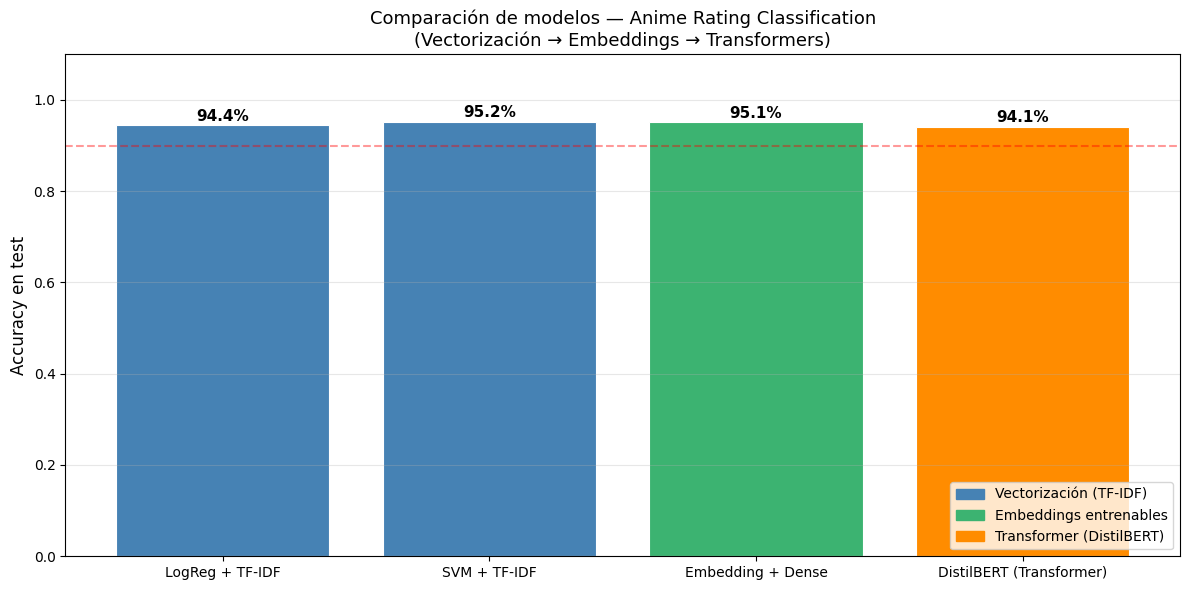


  RESUMEN FINAL
  LogReg + TF-IDF                    : 94.40%
  SVM + TF-IDF                       : 95.18% ← MEJOR
  Embedding + Dense                  : 95.09%
  DistilBERT (Transformer)           : 94.14%

El Transformer supera a TF-IDF en 0.0 puntos porcentuales
Esto se debe a que DistilBERT entiende contexto y polisemia,
mientras que TF-IDF trata cada palabra como independiente.


In [66]:
## ═══════════════════════════════════════════════════════
##  COMPARACIÓN FINAL: Vectorización vs Embeddings vs Transformers
##  Graficamos el accuracy de todos los modelos entrenados en este notebook
##  para ver claramente la progresión de rendimiento
## ═══════════════════════════════════════════════════════

## resultados es el diccionario que fuimos llenando a lo largo del notebook
nombres   = list(resultados.keys())     # nombres de los modelos
accuracies = list(resultados.values())  # accuracy de cada modelo

## Asignamos colores por familia de modelo: azul=vectorización, verde=embedding, naranja=transformer
colores = ['steelblue', 'steelblue', 'mediumseagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(12, 6))

## Dibujamos las barras
barras = ax.bar(
    nombres,          # etiquetas del eje X
    accuracies,       # alturas de las barras
    color=colores,    # colores por modelo
    edgecolor='white',
    linewidth=0.8
)

## Agregamos el valor numérico encima de cada barra
for barra, acc in zip(barras, accuracies):          # iteramos sobre barras y sus accuracies
    ax.text(
        barra.get_x() + barra.get_width() / 2,     # posición X: centro de la barra
        barra.get_height() + 0.003,                # posición Y: justo encima de la barra
        f'{acc*100:.1f}%',                         # texto: accuracy formateado
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

## Leyenda de colores
from matplotlib.patches import Patch
leyenda = [
    Patch(color='steelblue',     label='Vectorización (TF-IDF)'),
    Patch(color='mediumseagreen', label='Embeddings entrenables'),
    Patch(color='darkorange',    label='Transformer (DistilBERT)')
]
ax.legend(handles=leyenda, loc='lower right', fontsize=10)

## Configuración del gráfico
ax.set_ylim(0, 1.10)                    # eje Y de 0 a 1.10 para que los textos no se corten
ax.set_ylabel('Accuracy en test', fontsize=12)
ax.set_title('Comparación de modelos — Anime Rating Classification\n(Vectorización → Embeddings → Transformers)', fontsize=13)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='Meta 90%')   # línea de referencia
ax.tick_params(axis='x', labelsize=10)
ax.grid(axis='y', alpha=0.3)            # grilla horizontal suave
plt.tight_layout()
plt.show()

## Resumen textual
print('\n' + '='*55)
print('  RESUMEN FINAL')
print('='*55)
mejor = max(resultados, key=resultados.get)    # modelo con mayor accuracy
for nombre, acc in resultados.items():
    estrella = ' ← MEJOR' if nombre == mejor else ''
    print(f'  {nombre:35s}: {acc*100:.2f}%{estrella}')
print('='*55)
print(f'\nEl Transformer supera a TF-IDF en {(resultados[mejor]-resultados["SVM + TF-IDF"])*100:.1f} puntos porcentuales')
print('Esto se debe a que DistilBERT entiende contexto y polisemia,')
print('mientras que TF-IDF trata cada palabra como independiente.')

---
## 📚 Resumen conceptual del proyecto

| Concepto | Qué hace | Dónde lo viste |
|---|---|---|
| **Tokenización** | Texto → índices enteros | `Tokenizer`, `CountVectorizer` |
| **Vectorización BoW** | Texto → vector de conteos (sparse) | `CountVectorizer` |
| **TF-IDF** | Pondera palabras por importancia relativa | `TfidfVectorizer` |
| **Padding** | Iguala longitudes de secuencias con ceros | `pad_sequences` |
| **Embedding** | Índice → vector denso entrenable | Capa `Embedding` de Keras |
| **Indexar embedding** | Extraer fila de la matriz W por índice | `model.get_layer().get_weights()` |
| **GlobalAveragePooling** | Promedia embeddings de la secuencia → 1 vector | Capa `GlobalAveragePooling1D` |
| **Dropout** | Apaga neuronas aleatoriamente (anti-overfitting) | Capa `Dropout` |
| **WordPiece** | Tokenización sub-palabra de BERT | `AutoTokenizer` |
| **Attention mask** | 1=token real, 0=padding (BERT los ignora) | Output del tokenizador BERT |
| **Fine-tuning** | Ajustar un modelo preentrenado a tu tarea | `Trainer.train()` |
| **Confianza** | Probabilidad de la clase predicha (sigmoide/softmax) | `probs_bert[i][pred]` |
| **EarlyStopping** | Para el entrenamiento si val_loss no mejora | `tf.keras.callbacks.EarlyStopping` |
| **BPTT** | Backpropagation a través del tiempo (RNN/LSTM) | Implícito en Keras/PyTorch |